<a href="https://colab.research.google.com/github/ChanderValasai/gender-pay-gap-audit/blob/main/01_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive/')

import os
PROJECT_PATH = '/content/drive/MyDrive/data-analysis-projects/gender-pay-gap-audit'
os.chdir(PROJECT_PATH)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [9]:
import pandas as pd
df = pd.read_csv('data/raw/survey_results_public.csv')
print(df.shape)

/tmp/ipykernel_1077/1184589625.py:2: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/raw/survey_results_public.csv')


(49191, 172)


In [13]:
import pandas as pd

df = pd.read_csv('data/raw/survey_results_public.csv')
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

/tmp/ipykernel_1077/4151085639.py:3: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/raw/survey_results_public.csv')


Shape: (49191, 172)

Columns:
['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'AIThreat', 'NewRole', 'Too

In [14]:
print(df['Country'].value_counts().head(20))
print("\nPakistan count:", (df['Country'] == 'Pakistan').sum())

Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Canada                                                  1305
Ukraine                                                  964
Poland                                                   888
Netherlands                                              867
Italy                                                    835
Brazil                                                   825
Australia                                                804
Spain                                                    717
Sweden                                                   616
Switzerland                                              546
Czech Republic                                           520
Austria         

In [15]:
cols_needed = ['Country', 'ConvertedCompYearly', 'YearsCode', 'WorkExp', 'DevType', 'RemoteWork']

for col in cols_needed:
    missing = df[col].isna().sum()
    pct = round(missing / len(df) * 100, 1)
    print(f"{col}: {missing} missing ({pct}%)")

# Specifically for Pakistan subset
pk = df[df['Country'] == 'Pakistan']
print("\n--- Pakistan subset ---")
print("Total Pakistan rows:", len(pk))
print("Pakistan rows with non-null ConvertedCompYearly:", pk['ConvertedCompYearly'].notna().sum())
print("Pakistan rows with non-null YearsCode:", pk['YearsCode'].notna().sum())

Country: 13754 missing (28.0%)
ConvertedCompYearly: 25244 missing (51.3%)
YearsCode: 6149 missing (12.5%)
WorkExp: 6298 missing (12.8%)
DevType: 5511 missing (11.2%)
RemoteWork: 15411 missing (31.3%)

--- Pakistan subset ---
Total Pakistan rows: 239
Pakistan rows with non-null ConvertedCompYearly: 135
Pakistan rows with non-null YearsCode: 230


In [16]:
# Does salary missingness correlate with country-group in a way we should worry about?
pk_all = df[df['Country'] == 'Pakistan']
row_pk = df[df['Country'] != 'Pakistan']  # will include NaN countries too, we'll fix in cleaning

print("Pakistan salary response rate:", round(pk_all['ConvertedCompYearly'].notna().mean()*100, 1), "%")
print("Overall salary response rate:", round(df['ConvertedCompYearly'].notna().mean()*100, 1), "%")

Pakistan salary response rate: 56.5 %
Overall salary response rate: 48.7 %


In [17]:
pk_with_salary = pk_all[pk_all['ConvertedCompYearly'].notna()]
pk_without_salary = pk_all[pk_all['ConvertedCompYearly'].isna()]

print("Median YearsCode (Pakistan, has salary):", pk_with_salary['YearsCode'].median())
print("Median YearsCode (Pakistan, no salary):", pk_without_salary['YearsCode'].median())

Median YearsCode (Pakistan, has salary): 7.0
Median YearsCode (Pakistan, no salary): 5.5


## We will keep only rows where:

1. Country is not null AND equals either "Pakistan" or is used to build our "Rest of World" comparison group
2. ConvertedCompYearly is not null (our target variable — can't test what we don't have)
3. YearsCode is not null (our primary confounder)
4. We will also need to decide on outlier handling for salary — self-reported compensation surveys are notorious for fat-finger errors (e.g., someone typing $500,000,000 instead of $50,000)

In [18]:
# Step 1: Create the grouping variable
df_clean = df.copy()
df_clean['CountryGroup'] = df_clean['Country'].apply(
    lambda x: 'Pakistan' if x == 'Pakistan' else ('Rest of World' if pd.notna(x) else None)
)

# Step 2: Apply inclusion criteria
df_clean = df_clean[
    df_clean['CountryGroup'].notna() &
    df_clean['ConvertedCompYearly'].notna() &
    df_clean['YearsCode'].notna()
]

print("Rows after inclusion criteria:", df_clean.shape[0])
print(df_clean['CountryGroup'].value_counts())

Rows after inclusion criteria: 23838
CountryGroup
Rest of World    23706
Pakistan           132
Name: count, dtype: int64


In [19]:
# Look at the raw distribution first
print(df_clean['ConvertedCompYearly'].describe())

print("\n--- Percentiles ---")
for p in [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]:
    print(f"{int(p*100)}th percentile: {df_clean['ConvertedCompYearly'].quantile(p):,.0f}")

print("\n--- Pakistan-only distribution ---")
print(df_clean[df_clean['CountryGroup']=='Pakistan']['ConvertedCompYearly'].describe())

count    2.383800e+04
mean     1.019306e+05
std      4.627366e+05
min      1.000000e+00
25%      3.828500e+04
50%      7.541000e+04
75%      1.207232e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

--- Percentiles ---
1th percentile: 67
5th percentile: 2,790
25th percentile: 38,285
50th percentile: 75,410
75th percentile: 120,723
95th percentile: 232,029
99th percentile: 440,856

--- Pakistan-only distribution ---
count       132.000000
mean      13143.636364
std       20936.017101
min          35.000000
25%        2107.000000
50%        6321.000000
75%       16328.750000
max      175581.000000
Name: ConvertedCompYearly, dtype: float64


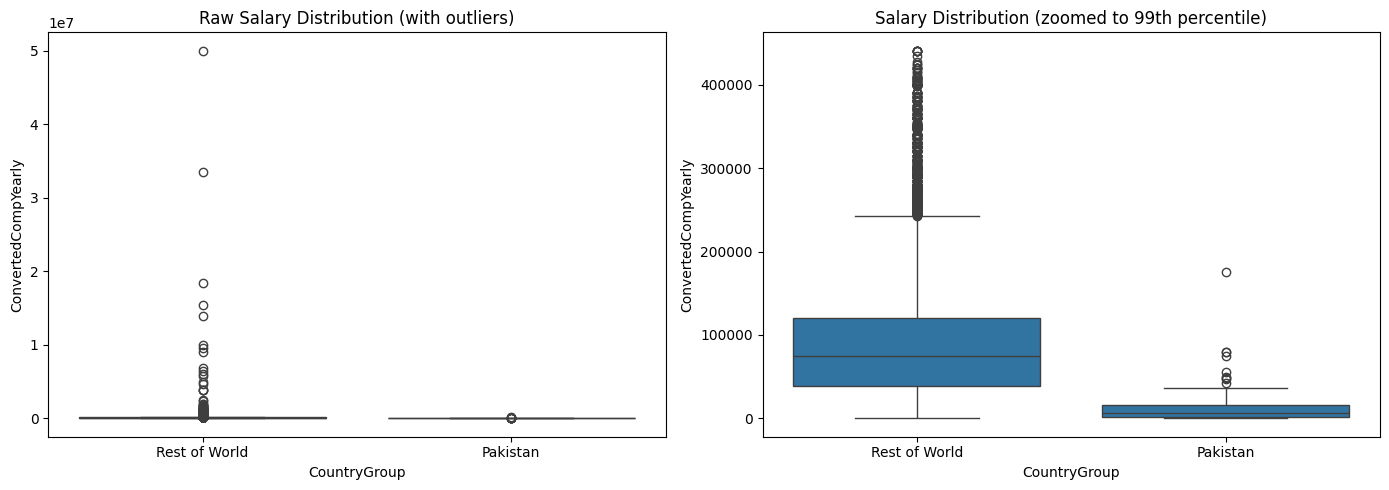

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot - full distribution, will look squashed due to outliers, that's expected
sns.boxplot(data=df_clean, x='CountryGroup', y='ConvertedCompYearly', ax=axes[0])
axes[0].set_title('Raw Salary Distribution (with outliers)')

# Boxplot - zoomed to 99th percentile to actually see the boxes
cap = df_clean['ConvertedCompYearly'].quantile(0.99)
sns.boxplot(data=df_clean[df_clean['ConvertedCompYearly'] <= cap],
            x='CountryGroup', y='ConvertedCompYearly', ax=axes[1])
axes[1].set_title('Salary Distribution (zoomed to 99th percentile)')

plt.tight_layout()
plt.show()